## Preamble

In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """
    Function to set matplotlib parameters for plotting.

    Parameters:
    dpi (int): Dots per inch for the plot. Default is 300.
    figsize (tuple): Figure size for the plot. Default is (18, 12).
    grid (bool): Whether to show grid in the plot. Default is True.
    font_size (int): Font size for the text in the plot. Default is 16.
    font_family (str): Font family for the text in the plot. Default is 'serif'.

    Returns:
    None

    This function updates the default parameters in matplotlib's rcParams dictionary to 
    customize the look and feel of matplotlib plots. The parameters include dots per inch (dpi) 
    for plot resolution, figure size, grid visibility, font size, and font family.
    """
    import matplotlib as mpl
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family
set_mpl_params()

In [2]:
# Importing required libraries for the entire notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

## You can find solutions for questions 1 in a pdf file on exercise page.

## Question 2

### Exploratory analysis

In [3]:
df = pd.read_csv("diseaseX.csv")
# Display random ten samples
df.sample(5)

,Cholesterol,Blood Pressure,Age,Height,Disease
106,0.279268,-2.348432,0.749900,-3.676233,0
1209,2.502281,4.367940,-0.657135,-1.749361,1
1621,3.417802,4.980435,-0.517757,-1.954340,1
145,4.560168,4.621773,-0.174648,0.988513,1
1318,-1.285591,-1.631143,0.116830,1.460173,0


In [4]:
# Print the size of the data
print("Dataset has the shape", df.shape)

Dataset has the shape (2000, 5)


In [5]:
# Print the count of missing values
print(df.isnull().sum())

Cholesterol       0
Blood Pressure    0
Age               0
Height            0
Disease           0
dtype: int64


In [6]:
# Remove missing values
data = df.dropna(axis=0)
print(data.isnull().sum())
print("Shape of the dataset", data.shape)

Cholesterol       0
Blood Pressure    0
Age               0
Height            0
Disease           0
dtype: int64
Shape of the dataset (2000, 5)


In [7]:
# Display statistical overview
data.describe()

,Cholesterol,Blood Pressure,Age,Height,Disease
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.549021,1.383547,-0.007664,0.015299,0.496500
std,1.893776,3.460589,1.016638,2.155748,0.500113
min,-3.176704,-5.190223,-3.221016,-4.276826,0.000000
25%,-0.041371,-1.953798,-0.698550,-1.991614,0.000000
50%,1.455517,0.944595,-0.026856,-0.069545,0.000000
75%,3.169344,4.755657,0.696639,2.013702,1.000000
max,6.317681,7.266347,3.098299,4.936006,1.000000


<Figure size 1350x900 with 0 Axes>

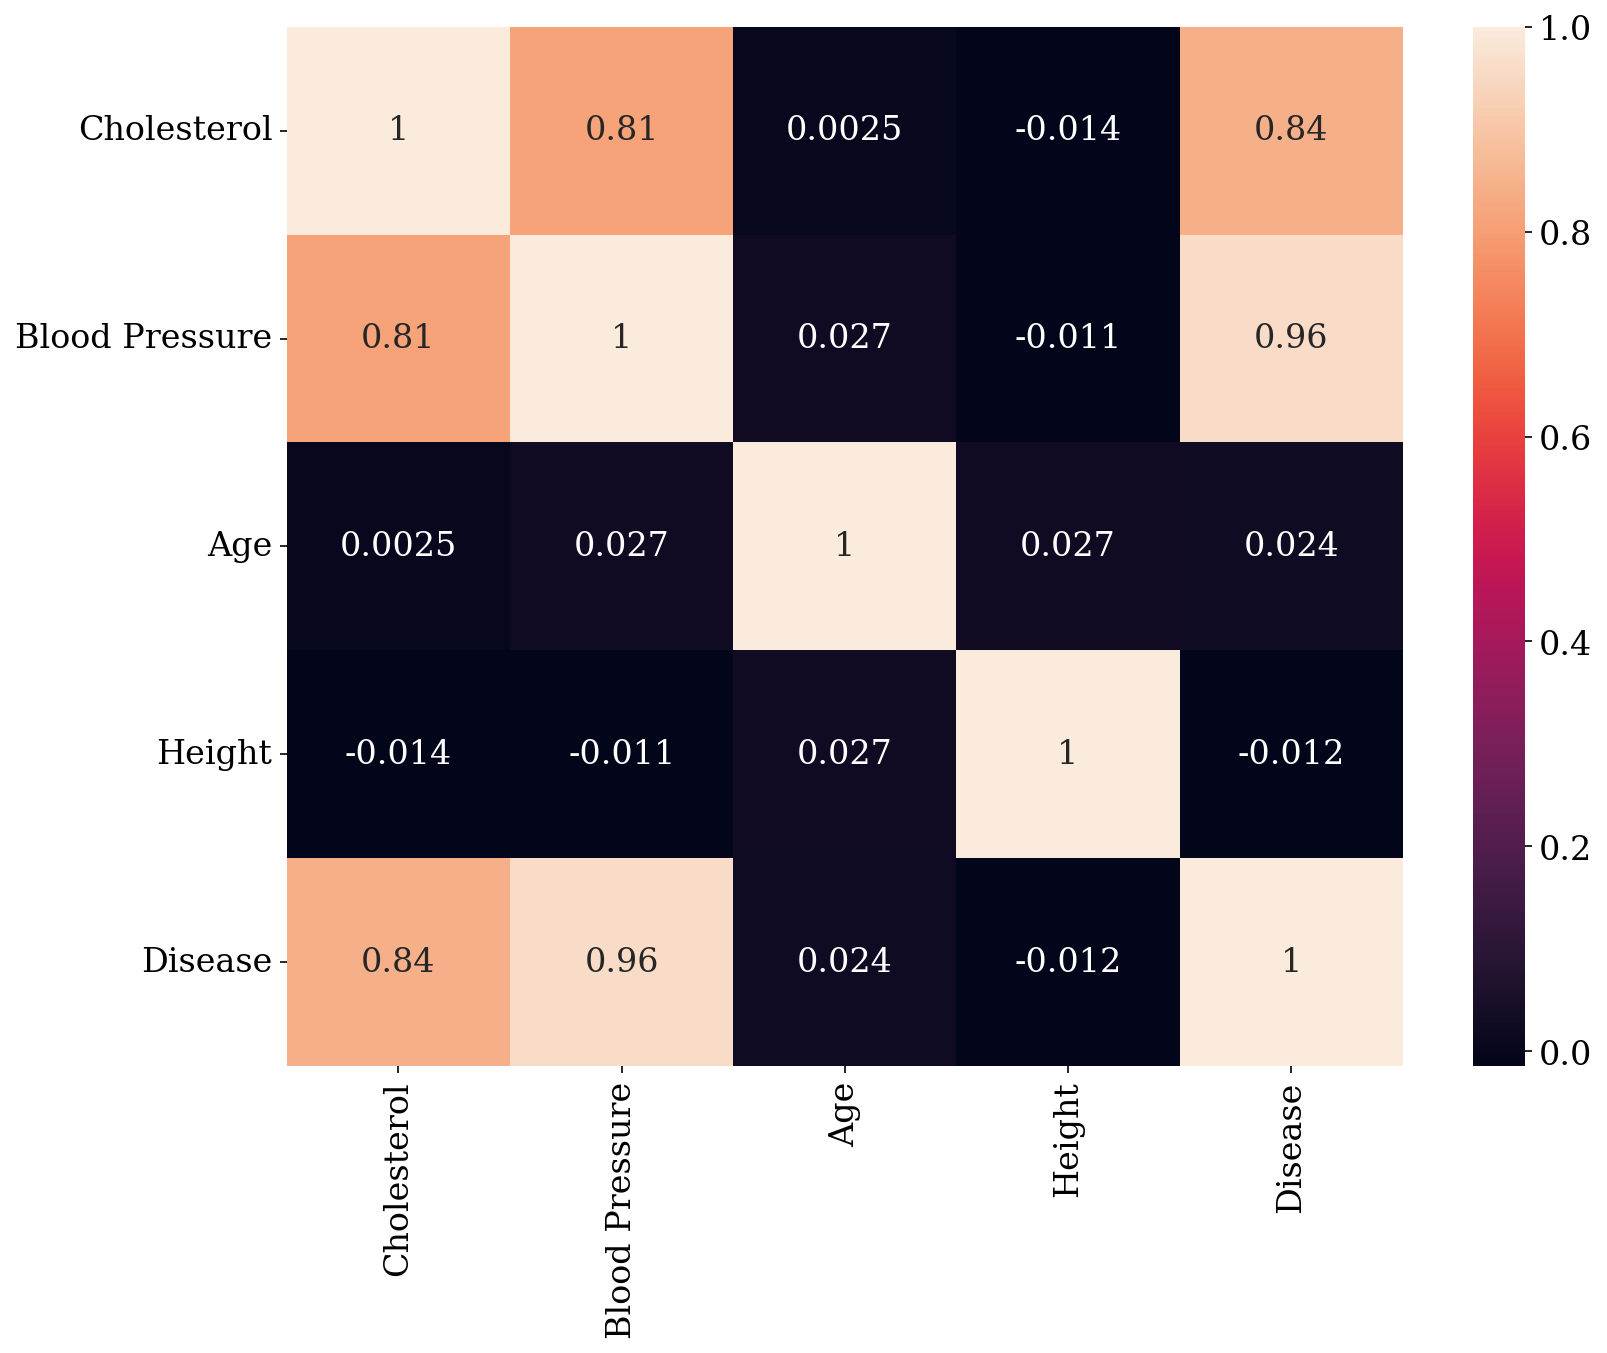

In [8]:
# Correlation matrix heat map
plt.figure()
corrmat = data.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True)
plt.grid()
plt.show()

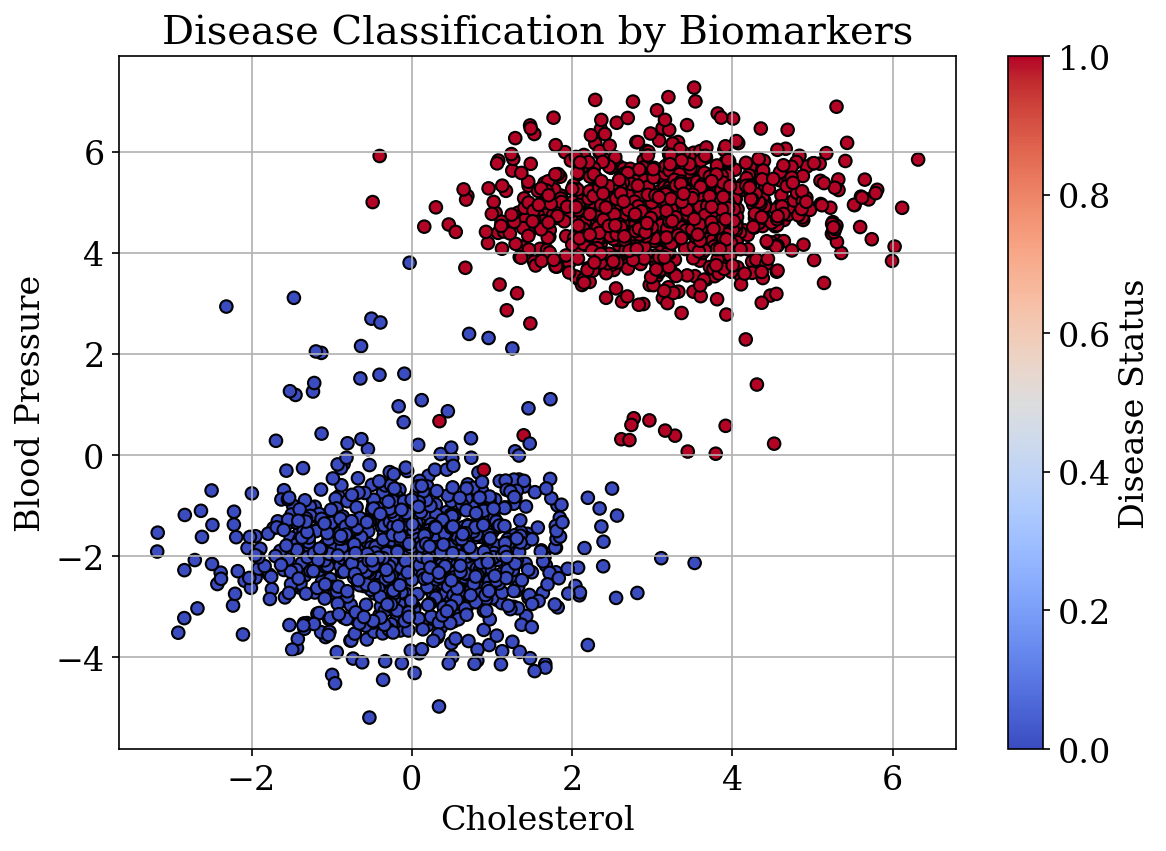

In [9]:
# Isolating informative features
X, y = data[["Cholesterol", "Blood Pressure"]].values, data[["Disease"]].values

# Create scatter plot with colors based on disease class
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.colorbar(label='Disease Status')
plt.xlabel('Cholesterol')
plt.ylabel('Blood Pressure')
plt.title('Disease Classification by Biomarkers')
plt.show()


### Gaussian Naive Bayes classifier

In [10]:
class GaussianNB:
    """Gaussian Naive Bayes classifier"""
    
    def fit(self, X, y):
        """
        Calculate mean, variance, and prior probabilities for each class
        """
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]
        
        # Store statistics for each class
        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)
        
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / X.shape[0]
        
        return self
    
    def _gaussian_pdf(self, x, mean, var):
        """
        Calculate Gaussian probability density
        """
        eps = 1e-9  # Prevent division by zero
        numerator = np.exp(-((x - mean) ** 2) / (2 * (var + eps)))
        denominator = np.sqrt(2 * np.pi * (var + eps))
        return numerator / denominator
    
    def predict(self, X):
        """
        Predict class for each sample
        """
        posteriors = []
        
        for idx, c in enumerate(self.classes):
            # Log probabilities to avoid numerical underflow
            prior = np.log(self.priors[idx])
            
            # Calculate likelihood for each feature (independence assumption)
            likelihood = np.sum(
                np.log(self._gaussian_pdf(X, self.mean[idx], self.var[idx])),
                axis=1
            )
            
            posterior = prior + likelihood # Since we are in log space:  posterior = prior × likelihood => log(posterior) = log(prior) + log(likelihood)
            posteriors.append(posterior)
        
        posteriors = np.array(posteriors).T
        return self.classes[np.argmax(posteriors, axis=1)]

In [11]:
def plot_decision_boundary(model, X, y, resolution=0.02):
    """
    Create decision boundary plot
    """
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )
    
    # Predict class for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), 
                         cmap='coolwarm', edgecolor='k')
    
    # Add colorbar
    cbar = plt.colorbar(scatter, label='Predicted Class')
    cbar.set_ticks([0, 1])
    
    # Custom legend
    legend_elements = [
        plt.scatter([], [], c='blue', label='Healthy'),
        plt.scatter([], [], c='red', label='Disease')
    ]
    plt.legend(handles=legend_elements)
    
    plt.xlabel("Cholesterol Level (standardized)")
    plt.ylabel("Blood Pressure (standardized)")


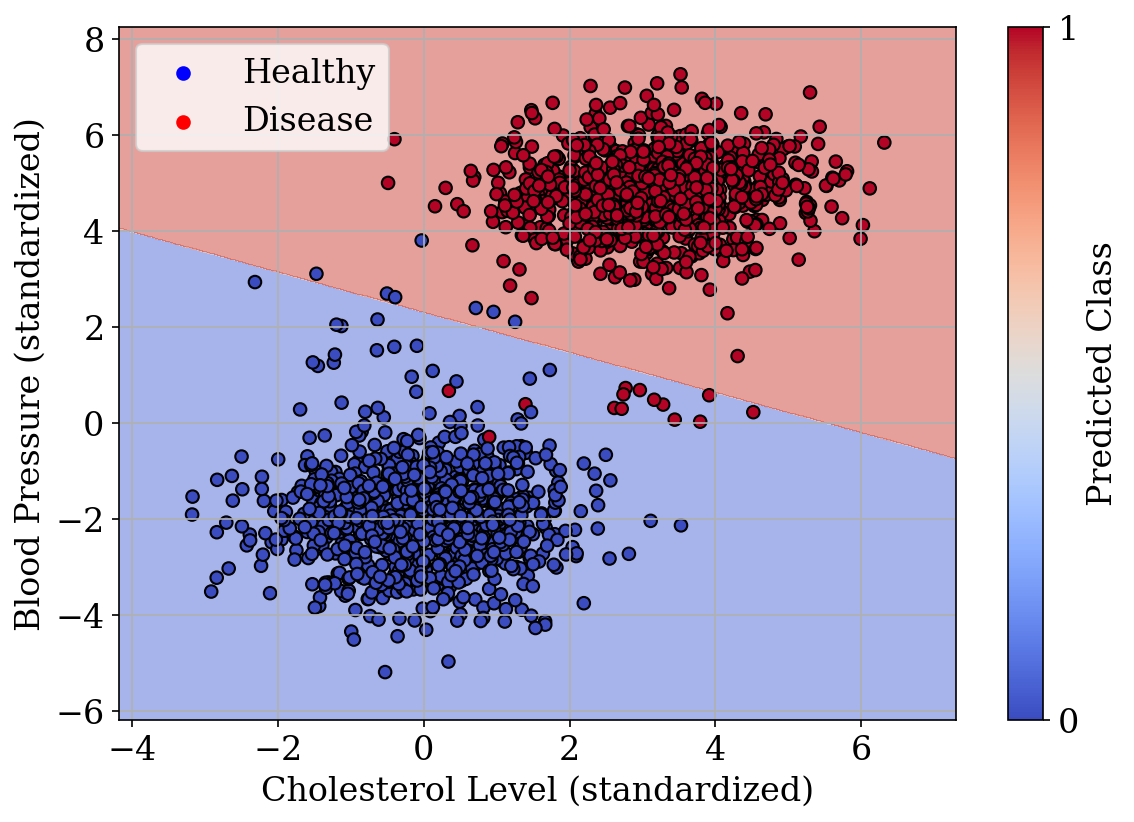

Accuracy: 0.985


In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = GaussianNB()
model.fit(X_train, y_train.ravel())

# Make predictions
predictions = model.predict(X_test)

# Plot decision boundary
plot_decision_boundary(model, X, y)
plt.show()

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")

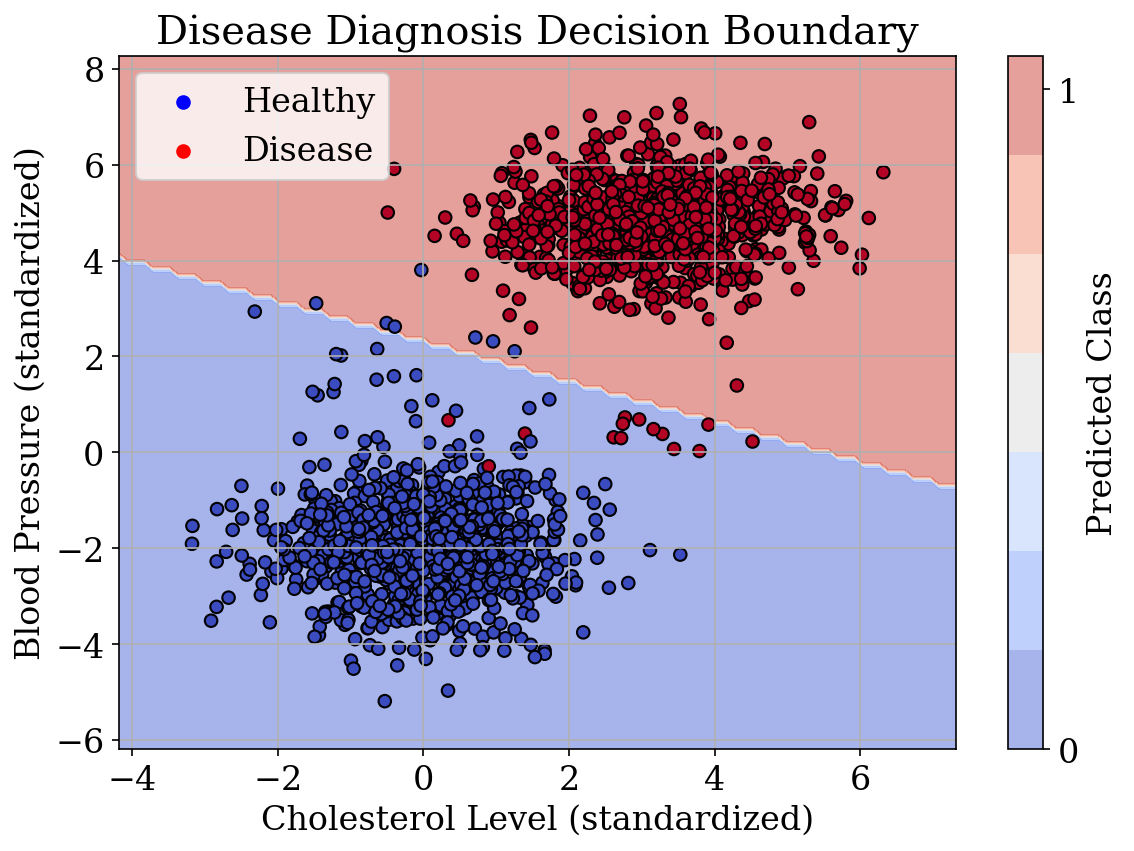

Accuracy: 0.985


In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Gaussian Nauve Bayes model training
model = GaussianNB()
model.fit(X_train, y_train.ravel())

# Make predictions
predictions = model.predict(X_test)

# Plot decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    model, X, response_method="predict",
    alpha=0.5, cmap='coolwarm'
)

# Create scatter plot with custom legend
scatter = disp.ax_.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolor='k')

# Add colorbar
cbar = plt.colorbar(disp.surface_, label='Predicted Class')
cbar.set_ticks([0, 1])
# Create custom legend
legend_elements = [plt.scatter([], [], c='blue', label='Healthy'),
                  plt.scatter([], [], c='red', label='Disease')]
plt.legend(handles=legend_elements)

plt.title("Disease Diagnosis Decision Boundary")
plt.xlabel("Cholesterol Level (standardized)")
plt.ylabel("Blood Pressure (standardized)")
plt.show()

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")


## Question 3

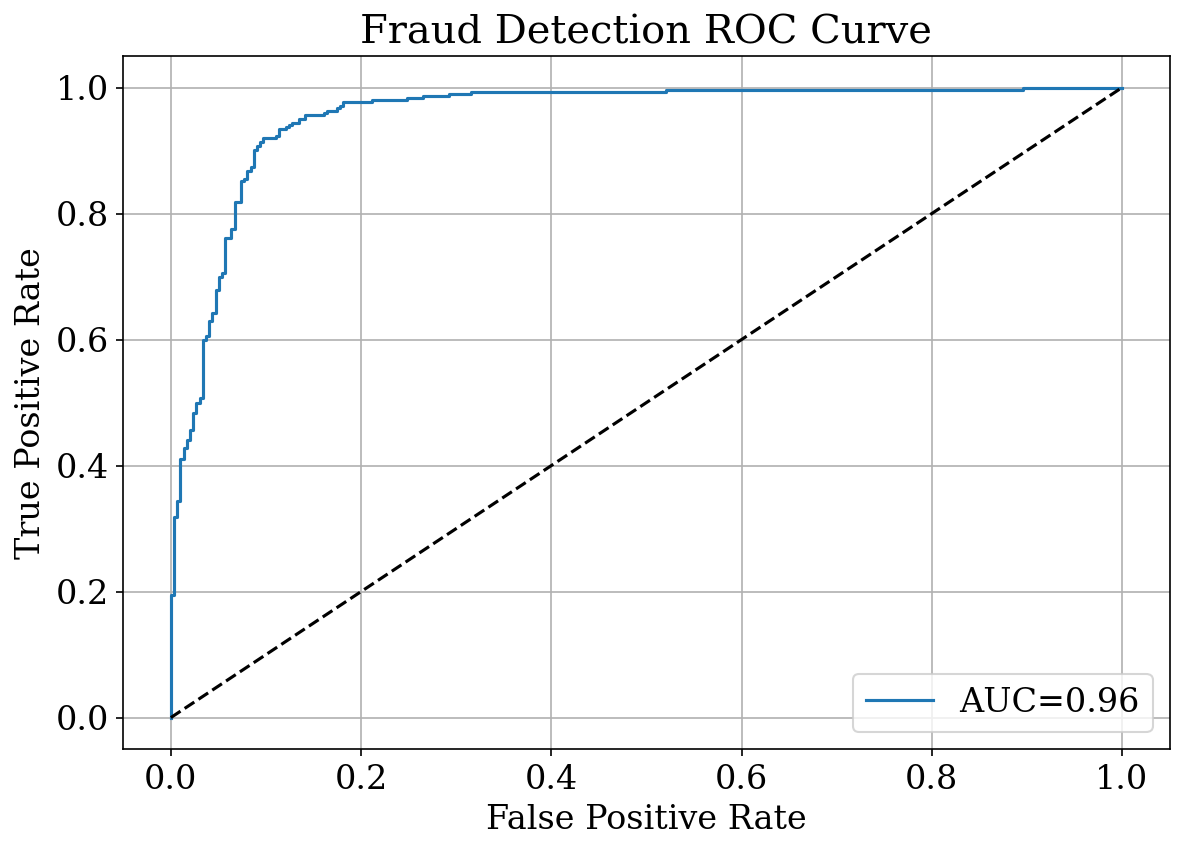

Bayes Error: 0.18


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Load the dataset
data = pd.read_csv("fraud_detection_dataset.csv")

# Split features and target
X = data.drop(columns=['is_fraud'])
y = data['is_fraud']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
bayes_error = 1 - max(tpr - fpr)

# Plot ROC Curve
plt.plot(fpr, tpr, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Fraud Detection ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"Bayes Error: {bayes_error:.2f}")

In [15]:
data.sample(5)

,transaction_amount,velocity_score,geographic_risk,daily_volume,distance_from_home,is_fraud
284,2.856106,0.919684,1.678614,-3.250083,0.924483,1
71,1.462224,1.257201,0.301973,-1.860926,-0.429335,1
1909,1.041194,-1.643877,0.569012,0.545063,1.705692,1
112,-2.663156,-1.194442,0.284422,1.740061,0.530856,0
844,1.800510,1.207690,1.033183,-2.564721,0.124429,1


## Question 4

A high school library section has 68 books:
- 31 are fiction and the rest are non-fiction
- 21/31 fiction books are categorized as mystery
- 8 non-fiction books are categorized as mystery
Find the probability that a randomly selected non-fiction is categorized as mystery.

In [16]:
# Given data
total_books = 68
fiction_books = 31
non_fiction_books = total_books - fiction_books
fiction_mystery = 21
non_fiction_mystery = 8

### Calculate prior probabilities
- $P(Fiction)$ is the prior probability of fiction
- $P(NonFiction)$ is the prior probability of non-fiction

In [17]:
P_fiction = fiction_books / total_books
P_non_fiction = non_fiction_books / total_books

print(f"Prior probability of fiction: {P_fiction:.4f}")
print(f"Prior probability of non-fiction: {P_non_fiction:.4f}")

Prior probability of fiction: 0.4559
Prior probability of non-fiction: 0.5441


### Bayes' equation

The Bayes' equation for finding the probability of randomly selecting a non-fiction book given that the book is from the historical section is:

$$P(NonFiction|Historical) = \frac{P(Historical|NonFiction) \cdot P(NonFiction)}{P(Historical)}$$

Where:
- $P(NonFiction|Historical)$ is the probability we're solving for
- $P(Historical|NonFiction)$ is the probability of a non-fiction book being historical
- $P(NonFiction)$ is the prior probability of non-fiction
- $P(Historical)$ is the total probability of historical books
ical books


### Calculate $P(Historical|NonFiction)$

In [18]:
non_fiction_historical = non_fiction_books - non_fiction_mystery
P_historical_given_non_fiction = non_fiction_historical / non_fiction_books

print(f"P(Historical|Non-fiction) = {P_historical_given_non_fiction:.4f}")

P(Historical|Non-fiction) = 0.7838


### Calculate $P(Historical)$

In [19]:
fiction_historical = fiction_books - fiction_mystery
total_historical = fiction_historical + non_fiction_historical
P_historical = total_historical / total_books

print(f"P(Historical) = {P_historical:.4f}")

P(Historical) = 0.5735


### Calculate $P(NonFiction|Historical)$ using Bayes' theorem

In [20]:
P_non_fiction_given_historical = (P_historical_given_non_fiction * P_non_fiction) / P_historical

print(f"P(Non-fiction|Historical) = {P_non_fiction_given_historical:.4f}")

P(Non-fiction|Historical) = 0.7436


## Question 5

In a glass bottle, there are marble balls in two colours: red and blue. These marble balls have been manufactured by two companies: A and B.

Given information:
- 20% marbles from manufacturer A, 80% from manufacturer B
- 90% of manufacturer A marbles are red
- 50% of manufacturer B marbles are red
- One marble is randomly selected and it's red

Question: What is the probability that the red marble is from manufacturer A?

### Solution
We'll solve this using Bayes' theorem:

$$P(A|R) = \frac{P(R|A) \cdot P(A)}{P(R)}$$

Where:
- $P(A|R)$ = Probability marble is from A given it's red
- $P(R|A)$ = Probability of red given manufacturer A
- $P(A)$ = Probability of manufacturer A
- $P(R)$ = Total probability of red marble

In [21]:
# Defining given probabilities
P_A = 0.2  # P(A)
P_B = 0.8  # P(B)
P_R_given_A = 0.9  # P(R|A)
P_R_given_B = 0.5  # P(R|B)

print(f"P(A) = {P_A:.4f}")
print(f"P(R|A) = {P_R_given_A:.4f}")

P(A) = 0.2000
P(R|A) = 0.9000


In [22]:
# Calculate P(A∩R)
P_A_and_R = P_A * P_R_given_A
print(f"P(A∩R) = P(A) × P(R|A) = {P_A_and_R:.4f}")

P(A∩R) = P(A) × P(R|A) = 0.1800


In [23]:
# Calculate P(B∩R)
P_B_and_R = P_B * P_R_given_B
print(f"P(B∩R) = P(B) × P(R|B) = {P_B_and_R:.4f}")

P(B∩R) = P(B) × P(R|B) = 0.4000


In [24]:
# Calculate total probability of red P(R)
P_R = P_A_and_R + P_B_and_R
print(f"P(R) = P(A∩R) + P(B∩R) = {P_R:.4f}")

P(R) = P(A∩R) + P(B∩R) = 0.5800


In [25]:
# Calculate final probability using Bayes' theorem
P_A_given_R = P_A_and_R / P_R
print(f"P(A|R) = {P_A_given_R:.4f}")

P(A|R) = 0.3103


This means there is approximately a 31.03% chance that the red marble we selected was manufactured by company A.

## Question 6

In [26]:
# Extracting the priors
def priors(dataset, class_labels):
    c1 = class_labels[0]
    c2 = class_labels[1]
    count_c1 = np.count_nonzero(dataset[:, 1] == c1)
    count_c2 = np.count_nonzero(dataset[:, 1] == c2)
    P1 = count_c1 / len(dataset)
    P2 = count_c2 / len(dataset)
    return P1, P2

In [27]:
# Class conditional probabilities
def cond_prob(dataset, class_labels, number_of_bins=20):
    lower = np.min(dataset[:, 0].astype(float))
    upper = np.max(dataset[:, 0].astype(float))
    bins = np.linspace(lower, upper, number_of_bins + 1)
    
    c1 = class_labels[0]
    c2 = class_labels[1]
    
    x_c1 = dataset[:, 0][dataset[:, 1] == c1].astype(float)
    x_c2 = dataset[:, 0][dataset[:, 1] == c2].astype(float)
    
    counts_c1, _ = np.histogram(x_c1, bins=bins)
    counts_c2, _ = np.histogram(x_c2, bins=bins)
    
    Px_given_c1 = counts_c1 / len(x_c1) if len(x_c1) > 0 else np.zeros_like(counts_c1)
    Px_given_c2 = counts_c2 / len(x_c2) if len(x_c2) > 0 else np.zeros_like(counts_c2)
    
    return Px_given_c1, Px_given_c2, bins

In [28]:
# Posterior probabilities
def post_prob(Pc1, Pc2, Px_given_c1, Px_given_c2):
    Pc_given_x = np.zeros((len(Px_given_c1), 2))
    for i in range(len(Px_given_c1)):
        Px = Px_given_c1[i] * Pc1 + Px_given_c2[i] * Pc2
        if Px == 0:
            Pc_given_x[i, 0] = 0
            Pc_given_x[i, 1] = 0
        else:
            Pc_given_x[i, 0] = (Px_given_c1[i] * Pc1) / Px
            Pc_given_x[i, 1] = (Px_given_c2[i] * Pc2) / Px
    return Pc_given_x

In [29]:
# Artificial data preparation

# features and class labels from the first distribution
mu_a, sigma_a = 20, 4 # mean and standard deviation
xa = np.random.normal(mu_a, sigma_a, (1000,1))
ya = np.full((1000,1),'a')

# features and class labels from the second distribution
mu_b, sigma_b = 25, 4 # mean and standard deviation
xb = np.random.normal(mu_b, sigma_b, (10000,1))
yb = np.full((10000,1),'b')

# Combine and shuffle data
train_data = np.concatenate((np.concatenate((xa, ya), axis=1), np.concatenate((xb, yb), axis=1)), axis=0)
np.random.shuffle(train_data)

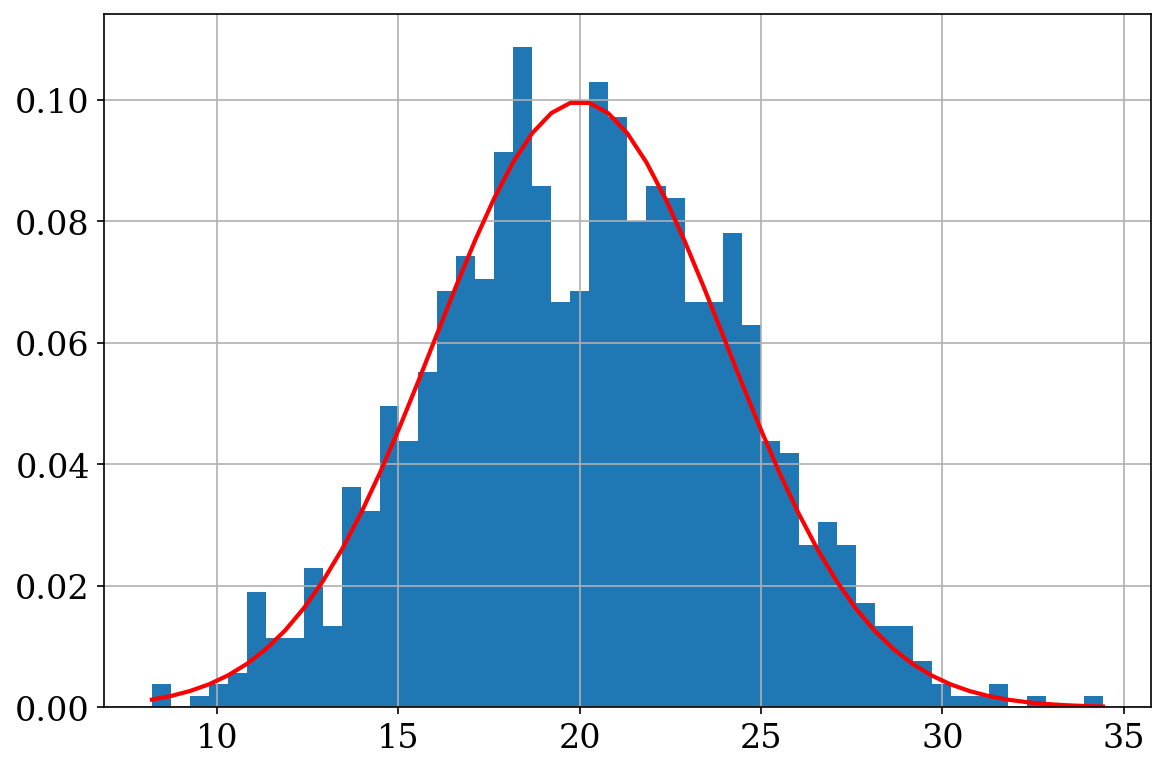

In [30]:
#plot distribution for class 'a'
count, bins, ignored = plt.hist(xa, 50, density=True)
plt.plot(bins, 1/(sigma_a * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu_a)**2 / (2 * sigma_a**2) ),linewidth=2, color='r')
plt.show()


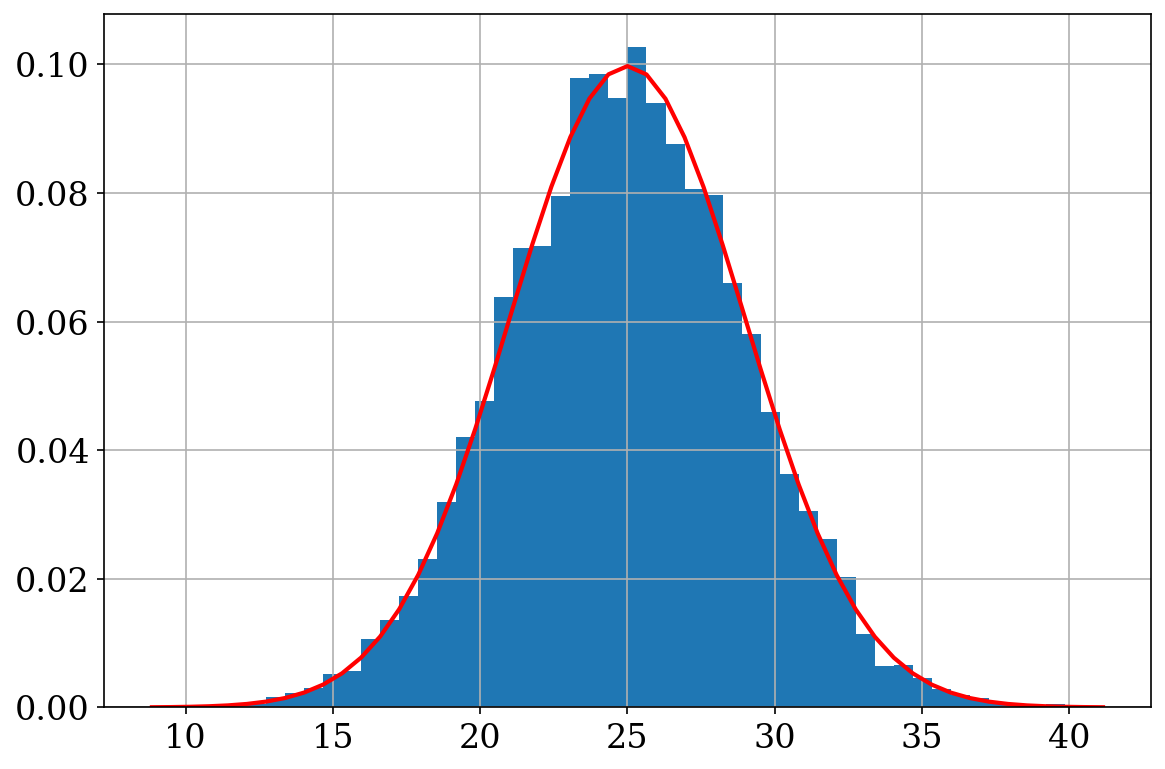

In [31]:
#plot distribution for class 'a'
count, bins, ignored = plt.hist(xb, 50, density=True)
plt.plot(bins, 1/(sigma_b * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu_b)**2 / (2 * sigma_b**2) ), linewidth=2, color='r')
plt.show()


In [32]:
# Generate test data
test_a = np.random.normal(mu_a, sigma_a, (50, 1))
test_b = np.random.normal(mu_b, sigma_b, (50, 1))
test_data = np.concatenate((
    np.concatenate((test_a, np.full((50, 1), 'a')), axis=1),
    np.concatenate((test_b, np.full((50, 1), 'b')), axis=1)), axis=0)
np.random.shuffle(test_data)

Bin Range		P(a|x)		P(b|x)
8.20-9.85	0.7500		0.2500
9.85-11.50	0.8500		0.1500
11.50-13.14	0.6250		0.3750
13.14-14.79	0.5604		0.4396
14.79-16.44	0.4476		0.5524
16.44-18.09	0.3213		0.6787
18.09-19.73	0.2132		0.7868
19.73-21.38	0.1348		0.8652
21.38-23.03	0.1003		0.8997
23.03-24.68	0.0668		0.9332
24.68-26.32	0.0429		0.9571
26.32-27.97	0.0306		0.9694
27.97-29.62	0.0162		0.9838
29.62-31.27	0.0081		0.9919
31.27-32.91	0.0077		0.9923
32.91-34.56	0.0075		0.9925
34.56-36.21	0.0000		1.0000
36.21-37.86	0.0000		1.0000
37.86-39.50	0.0000		1.0000
39.50-41.15	0.0000		1.0000


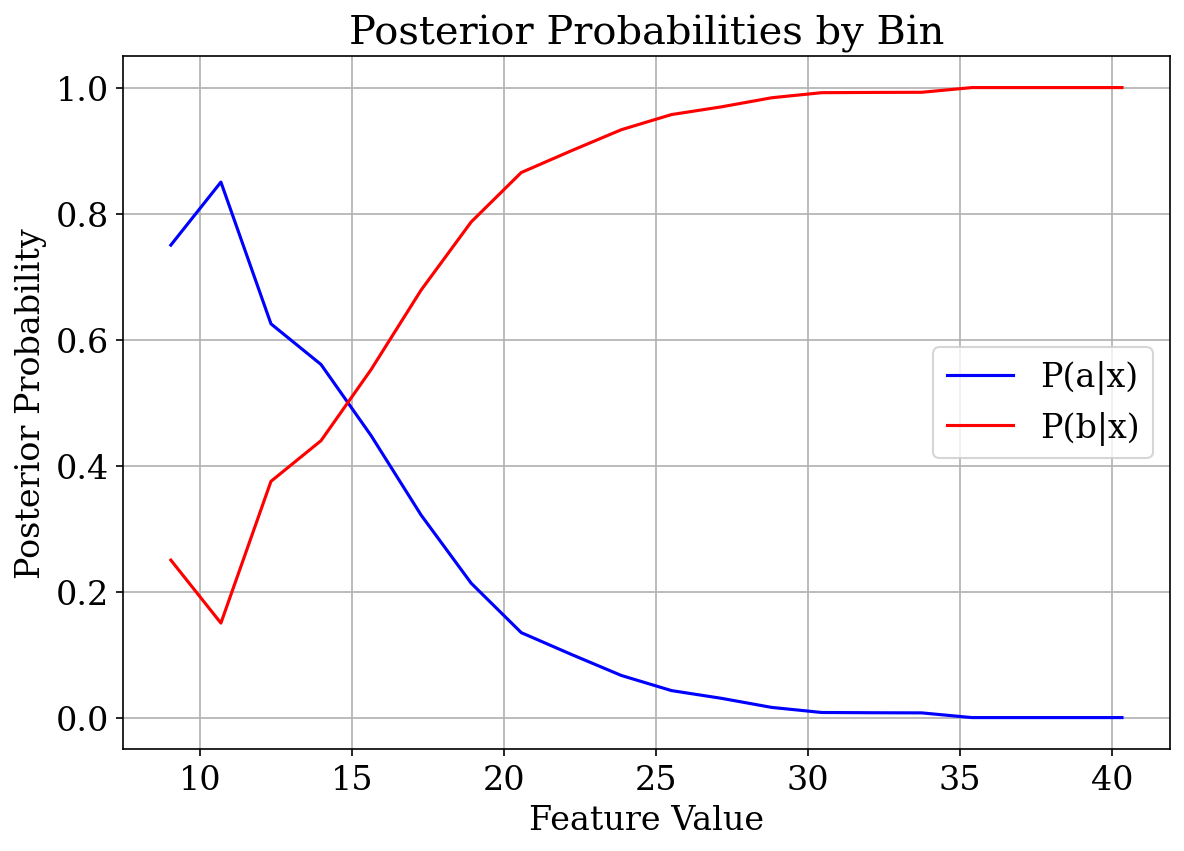

In [33]:
# Training Phase
Pa, Pb = priors(train_data, ['a', 'b'])
Px_given_a, Px_given_b, bins = cond_prob(train_data, ['a', 'b'], 20)
Pab_given_x = post_prob(Pa, Pb, Px_given_a, Px_given_b)

# Print posterior probabilities in tabular format
print("Bin Range\t\tP(a|x)\t\tP(b|x)")
for i in range(len(Pab_given_x)):
    bin_start = bins[i]
    bin_end = bins[i+1]
    print(f"{bin_start:.2f}-{bin_end:.2f}\t{Pab_given_x[i, 0]:.4f}\t\t{Pab_given_x[i, 1]:.4f}")

# Plot posterior probabilities
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure()
plt.plot(bin_centers, Pab_given_x[:, 0], 'b-', label='P(a|x)')
plt.plot(bin_centers, Pab_given_x[:, 1], 'r-', label='P(b|x)')
plt.xlabel('Feature Value')
plt.ylabel('Posterior Probability')
plt.legend()
plt.title('Posterior Probabilities by Bin')
plt.show()

In [34]:
# Testing Phase
def classify_instance(x, bins, posteriors, class_labels):
    bin_idx = np.digitize(x, bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(bins) - 2)
    prob_a = posteriors[bin_idx, 0]
    prob_b = posteriors[bin_idx, 1]
    return class_labels[0] if prob_a > prob_b else class_labels[1]

# Classify test data
test_features = test_data[:, 0].astype(float)
test_labels = test_data[:, 1]
predicted_labels = [classify_instance(x, bins, Pab_given_x, ['a', 'b']) for x in test_features]

# Calculate accuracy
accuracy = np.mean(np.array(predicted_labels) == test_labels)
print(f"\nClassification Accuracy: {accuracy * 100:.2f}%")


Classification Accuracy: 55.00%
